In [1]:
# Data handling libraries
import json
import numpy as np
import pandas as pd
from pandas import json_normalize
import torch
import typing as t
from torch.utils.data import TensorDataset, DataLoader

# Natural Language Processing (NLP) libraries
from nltk.corpus import stopwords

# Scikit-learn modeling libraries
from sklearn.dummy import DummyClassifier # For baseline model
from sklearn.feature_extraction.text import TfidfVectorizer # To convert text to numbers
from sklearn.linear_model import LogisticRegression # The classifier model
from sklearn.metrics import accuracy_score, classification_report # For evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score # For splitting and validating
from sklearn.pipeline import Pipeline # To chain processing steps
from matplotlib import pyplot as plt

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# 1. Data Loading

In [3]:
# Load the training data from a JSON Lines file (one JSON object per line)
train_data = pd.read_json('../Data/train.jsonl', lines=True)
# The tweet data is nested. json_normalize flattens the nested JSON into columns.
train_data = json_normalize(train_data.to_dict(orient='records'))

# Load the Kaggle test data (which we will make predictions on)
kaggle_data = pd.read_json('../Data/kaggle_test.jsonl', lines=True)
# Also normalize the Kaggle data
kaggle_data = json_normalize(kaggle_data.to_dict(orient='records'))


# Separate features from the target variable for the training set
X_train = train_data.drop('label', axis=1)
y_train = train_data['label']

X_kaggle = kaggle_data

# 2. Transforming into DataFrame

In [4]:
# Define a function to get the full text from a tweet object.
# Tweets can be truncated, storing the full version in 'extended_tweet.full_text'.
def extract_full_text(tweet):
    # Start with the standard 'text' field
    text = tweet['text']
    # Check if the 'extended_tweet.full_text' field exists (is not NaN)
    if not pd.isna(tweet['extended_tweet.full_text']):
        # If it exists, it's the full text, so use it instead
        text = tweet['extended_tweet.full_text']
    return text

# Apply this function to every row (axis=1) in the training data
X_train['full_text'] = X_train.apply(lambda tweet: extract_full_text(tweet), axis=1)
# Apply the same function to the Kaggle test data
X_kaggle['full_text'] = X_kaggle.apply(lambda tweet: extract_full_text(tweet), axis=1)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 3. Logistic Regression Classifier

In [7]:
# Load a list of common French stop words (e.g., 'le', 'la', 'de')
french_stop_words = stopwords.words('french')

print("\nBuilding model pipeline...")

# Create a scikit-learn Pipeline. This chains steps together.
# Data will flow from 'tfidf' (text to numbers) to 'clf' (classifier).
model_pipeline = Pipeline([
    # Step 1: TfidfVectorizer - converts text into a matrix of TF-IDF features
    ('tfidf', TfidfVectorizer(
        stop_words=french_stop_words, # Remove French stop words
        max_df=0.7,       # Ignore words that appear in > 70% of tweets (too common)
        min_df=3,         # Ignore words that appear in < 3 tweets (too rare)
        max_features=1000, # Keep only the top 1000 features
        ngram_range=(1, 2)  # Include 1-word (unigrams) and 2-word (bigrams) sequences
    )),
    # Step 2: Classifier - Logistic Regression
    ('clf', LogisticRegression(
        random_state=42,    # For reproducible results
        solver='liblinear'  # Good solver for this type of problem
    ))
])

print("\nRunning 5-Fold Cross-Validation on training data...")

# Use StratifiedKFold to ensure class proportions are maintained in each fold
# This is important for datasets that might be imbalanced
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score will train and test the pipeline 5 times
# using the K-fold splits of the *training data*
scores = cross_val_score(
    model_pipeline,          # The pipeline to evaluate
    X_train['full_text'],  # Features from training set
    y_train,               # Labels from training set
    cv=kfold,              # The stratified 5-fold splitter
    scoring='accuracy'     # The metric to evaluate
)

# Print the cross-validation results
print(f"K-Fold Accuracy Scores: {scores}")
print(f"Mean K-Fold Accuracy: {np.mean(scores) * 100:.2f}%")
print(f"Std Dev K-Fold Accuracy: {np.std(scores) * 100:.2f}%")


print("\nTraining final model on all training data...")
# Now that we've validated the model, train it on ALL available training data
model_pipeline.fit(X_train['full_text'], y_train)
print("Training complete.")

print("\n--- Final Model Evaluation on Held-Out Test Set ---")
# Use the trained pipeline to make predictions on the unseen Kaggle data
# The pipeline automatically applies the TF-IDF transform and then predicts
y_pred_test = model_pipeline.predict(X_kaggle['full_text'])

# Prepare the submission file
# Combine the 'challenge_id' from the Kaggle data with our predictions
output = pd.concat([X_kaggle['challenge_id'], pd.DataFrame(y_pred_test)], axis=1,ignore_index=True)
# Rename columns to match the required submission format
output.columns = ['ID', "Prediction"]
# Save the submission file as a CSV
output.to_csv('logistic_regression.csv', index=False)


Building model pipeline...

Running 5-Fold Cross-Validation on training data...
K-Fold Accuracy Scores: [0.6263112  0.62834458 0.62092115 0.62337411 0.63014008]
Mean K-Fold Accuracy: 62.58%
Std Dev K-Fold Accuracy: 0.33%

Training final model on all training data...
K-Fold Accuracy Scores: [0.6263112  0.62834458 0.62092115 0.62337411 0.63014008]
Mean K-Fold Accuracy: 62.58%
Std Dev K-Fold Accuracy: 0.33%

Training final model on all training data...
Training complete.

--- Final Model Evaluation on Held-Out Test Set ---
Training complete.

--- Final Model Evaluation on Held-Out Test Set ---


# 4. Dummy Classifier

In [8]:
print("\nTraining Dummy (Most Frequent)...")
# Create a DummyClassifier that always predicts the most frequent class
# This is a baseline to see if our Logistic Regression model is actually learning anything
dummy_mf = DummyClassifier(strategy="most_frequent")

# "Train" the dummy model (it just finds the most frequent class in y_train)
dummy_mf.fit(X_train['full_text'], y_train)

# Make predictions on the Kaggle data (it will predict the same class for all rows)
y_pred_test = dummy_mf.predict(X_kaggle['full_text'])

# Prepare and save the dummy submission file
output = pd.concat([X_kaggle['challenge_id'], pd.DataFrame(y_pred_test)], axis=1,ignore_index=True)
output.columns = ['ID', "Prediction"]
output.to_csv('dummy.csv', index=False)


Training Dummy (Most Frequent)...


# 5.1 Tokenizer (From Lab 4)

In [139]:
from nltk.tokenize import WordPunctTokenizer
from vocab import Vocab
from collections import Counter

tokenizer = WordPunctTokenizer()

# Build vocab
words = []
num_words = 10000

for text in X_train['full_text']:
    tokens = tokenizer.tokenize(text)
    words.extend(tokens)

top_words = dict(Counter(words).most_common(num_words))
voc = Vocab(top_words)

print(tokenizer.tokenize(X_train['full_text'].iloc[0]))
print(voc.forward(tokenizer.tokenize(X_train['full_text'].iloc[0])))

['@', 'yvanmamalof', '@', 'BioHospitalix', 'Maintenant', 'si', '😅', 'On', 'commence', 'à', 'dresser', 'des', 'chiens', 'renifleurs', 'pour', 'détecter', 'Le', 'covid', '🤔']
[2, 10000, 2, 4812, 1553, 80, 1147, 92, 598, 17, 10000, 21, 2841, 10000, 26, 4272, 55, 31, 540]


## Tokenizing the data sets

In [172]:
max_len = 50

def vectorize_sentences(tweets: t.Iterable[str], max_len: int, tokenizer) -> np.ndarray:
    """
    Converts an iterable of strings into an array encoded from the vocabulary
    """
    vectors = []
    for text in tweets:
        tokens = tokenizer.tokenize(text)
        v = voc.forward(tokens)
        if len(v) > max_len: 
            v = v[:max_len]
        if len(v) < max_len:
            tmp = np.full(max_len, voc.getPadding())
            tmp[:len(v)] = v
            v = tmp
        vectors.append(v)
    return np.array(vectors)

X_train_vectorized = vectorize_sentences(tweets=X_train['full_text'], max_len=max_len, tokenizer=tokenizer)
X_test_vectorized = vectorize_sentences(tweets=X_test['full_text'], max_len=max_len, tokenizer=tokenizer)
X_kaggle_vectorized = vectorize_sentences(tweets=X_kaggle['full_text'], max_len=max_len, tokenizer=tokenizer)

In [173]:
y_train = np.array(y_train).reshape(-1, 1)
y_test = np.array(y_test).reshape(-1, 1)

In [ ]:
batch_size = 64

trainset = TensorDataset(torch.from_numpy(X_train_vectorized).to(device), torch.from_numpy(y_train).float().to(device))
testset = TensorDataset(torch.from_numpy(X_test_vectorized).to(device), torch.from_numpy(y_test).float().to(device))
kaggleset = TensorDataset(torch.from_numpy(X_kaggle_vectorized).to(device))

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)
test_loader_kaggle = DataLoader(kaggleset, batch_size=batch_size, shuffle=False)

torch.Size([64, 50])

# 5. Position encoder (From Lab 5)

In [6]:
import torch
from torch import nn
import math

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, nhid, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, nhid)  #(max_len, nhid)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, nhid, 2).float() * (-math.log(10000.0) / nhid)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq_len, nhid)
        x = x + self.pe[: x.size(1), :].unsqueeze(0)
        return self.dropout(x)
    
class TransformerModel(nn.Module):
    def __init__(self, ntoken, nhead, nhid, nlayers, dropout=0.5):
        super(TransformerModel, self).__init__()
        '''
        ntokens: the size of vocabulary
        nhid: the hidden dimension of the model.
        We assume that embedding_dim = nhid
        nlayers: the number of nn.TransformerEncoderLayer in nn.TransformerEncoder
        nhead: the number of heads in the multiheadattention models
        dropout: the dropout value
        '''
        self.model_type = "Transformer"
        self.encoder = nn.Embedding(ntoken, nhid) # fill me, nhid = the dim_embed
        self.pos_encoder = PositionalEncoding(nhid, dropout) #fill me, the PositionalEncoding class is implemented in the next cell
        encoder_layers = nn.TransformerEncoderLayer(nhid, nhead, nhid, dropout, batch_first=True) #fill me we assume nhid = d_model = dim_feedforward
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, nlayers) #fill me
        self.nhid = nhid

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = (
            mask.float()
            .masked_fill(mask == 0, float("-inf"))
            .masked_fill(mask == 1, float(0.0))
        )
        return mask

    def init_weights(self):
        initrange = 0.1
        self.encoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src, src_mask):
        src = self.encoder(src) * math.sqrt(self.nhid)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src, src_mask)  # fill me
        return output


class ClassificationHead(nn.Module):
    def __init__(self, nhid, nclasses, dropout=0.1):
        super(ClassificationHead, self).__init__()
        # self.decoder = nn.Linear(nhid, nclasses)
        self.mlp = nn.Sequential(
            nn.Linear(nhid, nhid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(nhid, nclasses),
        )
        self.init_weights()

        
    def init_weights(self):
        initrange = 0.1
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                m.weight.data.uniform_(-initrange, initrange)
                m.bias.data.zero_()

    def forward(self, src):
        output = self.mlp(src)
        return output

class Model(nn.Module):
    def __init__(self, ntoken, nhead, nhid, nlayers, nclasses, dropout=0.5):
        super(Model, self).__init__()
        self.base = TransformerModel(ntoken, nhead, nhid, nlayers, dropout)
        self.classifier = ClassificationHead(nhid, nclasses)

    def forward(self, src, src_mask = None):
        # base model
        x = self.base(src, src_mask) #fill me

        x = x.mean(dim=1)

        # classifier returns (batch_size, nclasses)
        output = self.classifier(x)
        return output

## Training

In [8]:
def check_model_parameter_sizes(model: torch.nn.Module):
    
    # Number of groups of parameters
    print('Number of groups of parameters {}'.format(len(list(model.parameters()))))
    print('-'*55)
    # Print parameters

    total = 0
    for name, param in model.named_parameters():
        print(f"{name:17} : [{param.numel():6}] {param.size()}")
        total += param.numel()

    print(f"{'TOTAL':17} : [{total:6}]")

    print('-'*55)

In [9]:
from tqdm import tqdm
def train_model(model, train_loader, test_loader, optimizer, loss_criterion, num_epochs):
    iter = 0
    history_train_acc, history_val_acc, history_train_loss, history_val_loss = [], [], [], []
    best_accuracy = 0
    for epoch in range(num_epochs):
        for i, (samples, labels) in enumerate(train_loader):
            # Training mode
            model.train()

            #Load samples
            samples = samples.view(-1, max_len).to(device)
            # labels come from the TensorDataset as shape (batch, 1). Convert to 1D long for CrossEntropyLoss
            labels = labels.view(-1, 1).float().to(device)

            # Clear gradients with respect to parameters
            optimizer.zero_grad()

            #Forward pass to get output
            outputs = model(samples)
            
            loss = loss_criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            iter += 1

            if iter % 100 == 0:
                train_loss = loss.data.item()

                model.eval()

                correct = 0
                total = 0

                for samples, labels in test_loader:
                    samples = samples.view(-1, max_len).to(device)
                    labels = labels.view(-1, 1).float().to(device)


                    outputs = model(samples)  # (batch_size, nclasses)

                    
                    val_loss = loss_criterion(outputs, labels)

                    # multiclass prediction: choose argmax
                    probs = torch.sigmoid(outputs)
                    predicted = (probs > 0.5).float()
                    
                    total += labels.size(0)
                    correct += (predicted.cpu() == labels.cpu()).sum().item()
                
                accuracy = 100. * correct / total

                print(f'Iter: {iter:4} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss.item():2.3f} | Val Accuracy: {accuracy:.2f}')
                history_val_loss.append(val_loss.data.item())
                history_val_acc.append(round(accuracy, 2))
                history_train_loss.append(train_loss)

                # Save model when accuracy beats best accuracy
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    # We can load this best model on the validation set later
                    torch.save(model.state_dict(), 'best_model.pth')
    return (history_train_acc, history_val_acc, history_train_loss, history_val_loss)

In [36]:
def plot_losses(history_train_loss, history_val_loss):
    # Set plotting style
    #plt.style.use(('dark_background', 'bmh'))
    plt.style.use('bmh')
    plt.rc('axes', facecolor='none')
    plt.rc('figure', figsize=(16, 4))

    # Plotting loss graph
    plt.plot(history_train_loss, label='Train')
    plt.plot(history_val_loss, label='Validation')
    plt.title('Loss Graph')
    plt.legend()
    plt.show()

## Custom encoder

In [37]:
nhid = 64  # hidden dimension
nlayers = 2  # the number of nn.TransformerEncoderLayer in nn.TransformerEncoder
nhead = 4  # the number of heads in the multiheadattention models
dropout = 0.3  # the dropout value
nclasses = 1
ntoken = num_words + 2  # size of the vocabulary
nepochs = 20

model = Model(ntoken, nhead, nhid, nlayers, nclasses, dropout).to(device)
# Use CrossEntropyLoss for multiclass classification. It expects raw logits and
# labels as class indices (dtype long, shape (batch,)).
criterion = nn.BCEWithLogitsLoss()
lr = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

NameError: name 'num_words' is not defined

In [38]:
check_model_parameter_sizes(model)

Number of groups of parameters 29
-------------------------------------------------------
base.encoder.weight : [2048320] torch.Size([32005, 64])
base.transformer_encoder.layers.0.self_attn.in_proj_weight : [ 12288] torch.Size([192, 64])
base.transformer_encoder.layers.0.self_attn.in_proj_bias : [   192] torch.Size([192])
base.transformer_encoder.layers.0.self_attn.out_proj.weight : [  4096] torch.Size([64, 64])
base.transformer_encoder.layers.0.self_attn.out_proj.bias : [    64] torch.Size([64])
base.transformer_encoder.layers.0.linear1.weight : [  4096] torch.Size([64, 64])
base.transformer_encoder.layers.0.linear1.bias : [    64] torch.Size([64])
base.transformer_encoder.layers.0.linear2.weight : [  4096] torch.Size([64, 64])
base.transformer_encoder.layers.0.linear2.bias : [    64] torch.Size([64])
base.transformer_encoder.layers.0.norm1.weight : [    64] torch.Size([64])
base.transformer_encoder.layers.0.norm1.bias : [    64] torch.Size([64])
base.transformer_encoder.layers.0.norm

In [39]:
(train_acc, val_acc, train_loss, val_loss) = train_model(model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, loss_criterion=criterion, num_epochs=nepochs)

Iter:  100 | Train Loss: 0.709 | Val Loss: 0.912 | Val Accuracy: 59.67
Iter:  200 | Train Loss: 0.711 | Val Loss: 0.822 | Val Accuracy: 60.43
Iter:  300 | Train Loss: 0.692 | Val Loss: 0.910 | Val Accuracy: 62.63
Iter:  400 | Train Loss: 0.649 | Val Loss: 0.898 | Val Accuracy: 62.31
Iter:  500 | Train Loss: 0.662 | Val Loss: 0.870 | Val Accuracy: 63.13
Iter:  600 | Train Loss: 0.667 | Val Loss: 0.883 | Val Accuracy: 62.85
Iter:  700 | Train Loss: 0.616 | Val Loss: 0.776 | Val Accuracy: 62.90
Iter:  800 | Train Loss: 0.561 | Val Loss: 0.871 | Val Accuracy: 63.40
Iter:  900 | Train Loss: 0.688 | Val Loss: 0.848 | Val Accuracy: 62.46
Iter: 1000 | Train Loss: 0.668 | Val Loss: 0.807 | Val Accuracy: 62.97


KeyboardInterrupt: 

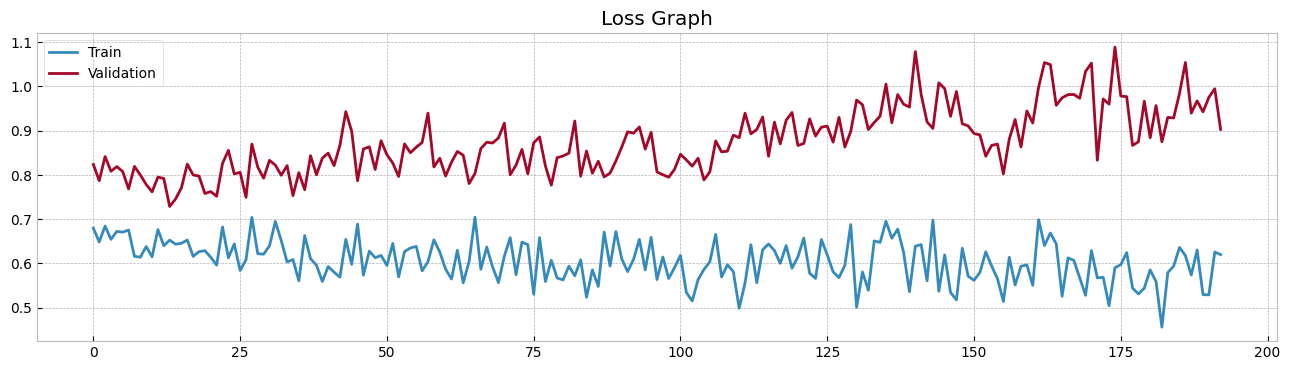

In [236]:
plot_losses(train_loss, val_loss)

In [11]:
def save_model(model):
    model.eval()

    all_preds = []

    with torch.no_grad():
        for samples in test_loader_kaggle:  # batch from Kaggle vectorized data
            samples = samples[0].to(device)               # (batch, max_len)
            logits = model(samples)                    # (batch, 1)

            probs = torch.sigmoid(logits).cpu().numpy()  # convertir en probas
            predicted = (probs > 0.5).astype(int)
            all_preds.append(predicted)

    # concatène tous les batches
    all_preds = np.vstack(all_preds).reshape(-1)

    # création du fichier Kaggle
    output = pd.DataFrame({
        "ID": X_kaggle['challenge_id'],
        "Prediction": all_preds
    })

    output.to_csv("submission.csv", index=False)
    print("Submission saved.")

In [165]:
save_model(model)

Submission saved.


# 6. Using AutoTokenizer

In [15]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base")

max_len = 50

def vectorize_sentences_camembert(tweets, max_len=max_len):
    enc = tokenizer(list(tweets.values), 
                    padding="max_length", 
                    truncation=True, 
                    max_length=max_len, 
                    return_tensors="np")
    return enc['input_ids']

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


In [16]:
X_train_vectorized = np.array(vectorize_sentences_camembert(X_train['full_text']))
X_test_vectorized = np.array(vectorize_sentences_camembert(X_test['full_text']))
X_kaggle_vectorized = np.array(vectorize_sentences_camembert(X_kaggle['full_text']))

y_train = np.array(y_train).reshape(-1, 1)
y_test = np.array(y_test).reshape(-1, 1)

In [17]:
batch_size = 128

trainset = TensorDataset(torch.from_numpy(X_train_vectorized).to(device), torch.from_numpy(y_train).float().to(device))
testset = TensorDataset(torch.from_numpy(X_test_vectorized).to(device), torch.from_numpy(y_test).float().to(device))
kaggleset = TensorDataset(torch.from_numpy(X_kaggle_vectorized).to(device))

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)
test_loader_kaggle = DataLoader(kaggleset, batch_size=batch_size, shuffle=False)

In [18]:
nhid = 64  # hidden dimension
nlayers = 2  # the number of nn.TransformerEncoderLayer in nn.TransformerEncoder
nhead = 4  # the number of heads in the multiheadattention models
dropout = 0.1  # the dropout value
nclasses = 1
ntoken = tokenizer.vocab_size
nepochs = 20

model = Model(ntoken, nhead, nhid, nlayers, nclasses, dropout).to(device)
# Use CrossEntropyLoss for multiclass classification. It expects raw logits and
# labels as class indices (dtype long, shape (batch,)).
criterion = nn.BCEWithLogitsLoss()
lr = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

(train_acc, val_acc, train_loss, val_loss) = train_model(model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, loss_criterion=criterion, num_epochs=nepochs)

Iter:  100 | Train Loss: 0.660 | Val Loss: 0.759 | Val Accuracy: 60.46
Iter:  200 | Train Loss: 0.632 | Val Loss: 0.751 | Val Accuracy: 60.98
Iter:  300 | Train Loss: 0.666 | Val Loss: 0.669 | Val Accuracy: 61.85
Iter:  400 | Train Loss: 0.640 | Val Loss: 0.672 | Val Accuracy: 62.33
Iter:  500 | Train Loss: 0.667 | Val Loss: 0.658 | Val Accuracy: 62.21
Iter:  600 | Train Loss: 0.716 | Val Loss: 0.646 | Val Accuracy: 62.45
Iter:  700 | Train Loss: 0.657 | Val Loss: 0.671 | Val Accuracy: 62.61
Iter:  800 | Train Loss: 0.624 | Val Loss: 0.689 | Val Accuracy: 62.90
Iter:  900 | Train Loss: 0.672 | Val Loss: 0.712 | Val Accuracy: 63.01
Iter: 1000 | Train Loss: 0.650 | Val Loss: 0.701 | Val Accuracy: 62.86
Iter: 1100 | Train Loss: 0.594 | Val Loss: 0.684 | Val Accuracy: 62.98
Iter: 1200 | Train Loss: 0.614 | Val Loss: 0.661 | Val Accuracy: 63.20
Iter: 1300 | Train Loss: 0.647 | Val Loss: 0.715 | Val Accuracy: 62.54
Iter: 1400 | Train Loss: 0.603 | Val Loss: 0.684 | Val Accuracy: 63.22
Iter: 

# Using Camembert Encoder

In [ ]:
from transformers import AutoModel

class CamembertClassifier(nn.Module):
    def __init__(self, nclasses=1, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("camembert-base")
        hidden_size = self.encoder.config.hidden_size  # 768
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, nclasses),
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        cls = outputs.last_hidden_state[:, 0, :]  # token [CLS]
        logits = self.classifier(cls)             # (batch, 1)
        return logits

### Training with Camembert

In [ ]:
def train_model(model, train_loader, test_loader, optimizer, loss_criterion, num_epochs):
    iter = 0
    history_train_acc, history_val_acc, history_train_loss, history_val_loss = [], [], [], []
    best_accuracy = 0
    for epoch in range(num_epochs):
        for i, (input_ids, attention_mask, labels) in enumerate(train_loader):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.view(-1, 1).float().to(device)

            # Training mode
            model.train()

            # Clear gradients with respect to parameters
            optimizer.zero_grad()

            outputs = model(input_ids, attention_mask)  # CamembertClassifier
            loss = loss_criterion(outputs, labels)


            #Forward pass to get output

            loss.backward()

            optimizer.step()

            iter += 1

            if iter % 100 == 0:
                train_loss = loss.data.item()

                model.eval()

                correct = 0
                total = 0

                for samples, labels in test_loader:
                    samples = samples.view(-1, max_len).to(device)
                    labels = labels.view(-1, 1).float().to(device)


                    outputs = model(samples)  # (batch_size, nclasses)
    for epoch in range(num_epochs):
        for i, (input_ids, attention_mask, labels) in enumerate(train_loader):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.view(-1, 1).float().to(device)

            # Training mode
            model.train()

            # Clear gradients with respect to parameters
            optimizer.zero_grad()

            outputs = model(input_ids, attention_mask)  # CamembertClassifier
            loss = loss_criterion(outputs, labels)


            #Forward pass to get output

            loss.backward()

            optimizer.step()

            iter += 1

            if iter % 100 == 0:
                train_loss = loss.data.item()

                model.eval()

                correct = 0
                total = 0

                for samples, labels in test_loader:
                    samples = samples.view(-1, max_len).to(device)
                    labels = labels.view(-1, 1).float().to(device)


                    outputs = model(samples)  # (batch_size, nclasses)
    for epoch in range(num_epochs):
        for i, (input_ids, attention_mask, labels) in enumerate(train_loader):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.view(-1, 1).float().to(device)

            # Training mode
            model.train()

            # Clear gradients with respect to parameters
            optimizer.zero_grad()

            outputs = model(input_ids, attention_mask)  # CamembertClassifier
            loss = loss_criterion(outputs, labels)


            #Forward pass to get output

            loss.backward()

            optimizer.step()

            iter += 1

            if iter % 100 == 0:
                train_loss = loss.data.item()

                model.eval()

                correct = 0
                total = 0

                for samples, labels in test_loader:
                    samples = samples.view(-1, max_len).to(device)
                    labels = labels.view(-1, 1).float().to(device)


                    outputs = model(samples)  # (batch_size, nclasses)

                    
                    val_loss = loss_criterion(outputs, labels)

                    # multiclass prediction: choose argmax
                    probs = torch.sigmoid(outputs)
                    predicted = (probs > 0.5).float()
                    
                    total += labels.size(0)
                    correct += (predicted.cpu() == labels.cpu()).sum().item()
                
                accuracy = 100. * correct / total

                print(f'Iter: {iter:4} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss.item():2.3f} | Val Accuracy: {accuracy:.2f}')
                history_val_loss.append(val_loss.data.item())
                history_val_acc.append(round(accuracy, 2))
                history_train_loss.append(train_loss)

                # Save model when accuracy beats best accuracy
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    # We can load this best model on the validation set later
                    torch.save(model.state_dict(), 'best_model.pth')
    return (history_train_acc, history_val_acc, history_train_loss, history_val_loss)

In [25]:
def camembert_embedding(tweets, max_len=max_len):
    enc = tokenizer(list(tweets.values), 
                    padding="max_length", 
                    truncation=True, 
                    max_length=max_len, 
                    return_tensors="np")
    return enc['input_ids']


In [26]:
X_train_vectorized = np.array(camembert_embedding(X_train['full_text']))
X_test_vectorized = np.array(camembert_embedding(X_test['full_text']))
X_kaggle_vectorized = np.array(camembert_embedding(X_kaggle['full_text']))

y_train = np.array(y_train).reshape(-1, 1)
y_test = np.array(y_test).reshape(-1, 1)

batch_size = 128

trainset = TensorDataset(torch.from_numpy(X_train_vectorized).to(device), torch.from_numpy(y_train).float().to(device))
testset = TensorDataset(torch.from_numpy(X_test_vectorized).to(device), torch.from_numpy(y_test).float().to(device))
kaggleset = TensorDataset(torch.from_numpy(X_kaggle_vectorized).to(device))

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)
test_loader_kaggle = DataLoader(kaggleset, batch_size=batch_size, shuffle=False)

In [24]:
nhid = 64  # hidden dimension
nlayers = 2  # the number of nn.TransformerEncoderLayer in nn.TransformerEncoder
nhead = 4  # the number of heads in the multiheadattention models
dropout = 0.1  # the dropout value
nclasses = 1
ntoken = tokenizer.vocab_size
nepochs = 20

model = Model(ntoken, nhead, nhid, nlayers, nclasses, dropout).to(device)
# Use CrossEntropyLoss for multiclass classification. It expects raw logits and
# labels as class indices (dtype long, shape (batch,)).
criterion = nn.BCEWithLogitsLoss()
lr = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

(train_acc, val_acc, train_loss, val_loss) = train_model(model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, loss_criterion=criterion, num_epochs=nepochs)

AssertionError: only bool and floating types of mask are supported